<a href="https://colab.research.google.com/github/utlia/employee-attrition-prediction/blob/main/employee_attrition_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Explore Dataset

In [258]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [259]:
pd.set_option('display.max_columns', None)

In [260]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [261]:
employee_df = pd.read_csv('/content/drive/My Drive/Colab Notebooks/Data Science for Business/Human_Resources.csv')
employee_df


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,3,Male,41,4,2,Laboratory Technician,4,Married,2571,12290,4,Y,No,17,3,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,4,Male,42,2,3,Healthcare Representative,1,Married,9991,21457,4,Y,No,15,3,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,2,Male,87,4,2,Manufacturing Director,2,Married,6142,5174,1,Y,Yes,20,4,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,4,Male,63,2,2,Sales Executive,2,Married,5390,13243,2,Y,No,14,3,4,80,0,17,3,2,9,6,0,8


dari tabel dataset diatas, terlihat ada skitar 1469 employee yang terecord diperusahaan tersebut,dengan beberapa point tabel (35 kolom). diantaranya yaitu point jam kerjanya, department dia bekerja, jarak rumah karyawan ke kantor, pendidikan, status pernikahan dsb .

In [262]:
employee_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [263]:
#informasi berdasarkan tabel diatas ada total 34 element tabel dengan 26 tipe tabel interger dan 9 tipe object
employee_df.describe()
#bisa dilihat dari hasil ringkasan dari nilai terendah, nilai maksimum, rata dari tiap element tabel.

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,2.728571,6502.931293,14313.103401,2.693197,15.209524,3.153741,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,1.102846,4707.956783,7117.786044,2.498009,3.659938,0.360824,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,1.000000,1009.000000,2094.000000,0.000000,11.000000,3.000000,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,2.000000,2911.000000,8047.000000,1.000000,12.000000,3.000000,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,3.000000,4919.000000,14235.500000,2.000000,14.000000,3.000000,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,4.000000,8379.000000,20461.500000,4.000000,18.000000,3.000000,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,4.000000,19999.000000,26999.000000,9.000000,25.000000,4.000000,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [264]:
### Task 3 Visual Dataset

In [265]:
#lets replace 'Attritition', 'Overtime', 'Over18' with integers before permorming any visualizations.
#tahap ini merubah tabel Attrition ke bentuk numerik 1/0
employee_df['Attrition'] = employee_df['Attrition'].apply(lambda x:1 if x == 'Yes' else 0)
employee_df

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,0,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,3,Male,41,4,2,Laboratory Technician,4,Married,2571,12290,4,Y,No,17,3,3,80,1,17,3,3,5,2,0,3
1466,39,0,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,4,Male,42,2,3,Healthcare Representative,1,Married,9991,21457,4,Y,No,15,3,1,80,1,9,5,3,7,7,1,7
1467,27,0,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,2,Male,87,4,2,Manufacturing Director,2,Married,6142,5174,1,Y,Yes,20,4,2,80,1,6,0,3,6,2,0,3
1468,49,0,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,4,Male,63,2,2,Sales Executive,2,Married,5390,13243,2,Y,No,14,3,4,80,0,17,3,2,9,6,0,8


In [266]:
employee_df['OverTime'] = employee_df['OverTime'].apply(lambda x:1 if x == 'Yes' else 0)
employee_df['Over18'] = employee_df['Over18'].apply(lambda x:1 if x == 'Y' else 0)


In [267]:
print(employee_df['Attrition'].value_counts())

Attrition
0    1233
1     237
Name: count, dtype: int64


In [268]:
employee_df.tail()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1465,36,0,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,3,Male,41,4,2,Laboratory Technician,4,Married,2571,12290,4,1,0,17,3,3,80,1,17,3,3,5,2,0,3
1466,39,0,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,4,Male,42,2,3,Healthcare Representative,1,Married,9991,21457,4,1,0,15,3,1,80,1,9,5,3,7,7,1,7
1467,27,0,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,2,Male,87,4,2,Manufacturing Director,2,Married,6142,5174,1,1,1,20,4,2,80,1,6,0,3,6,2,0,3
1468,49,0,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,4,Male,63,2,2,Sales Executive,2,Married,5390,13243,2,1,0,14,3,4,80,0,17,3,2,9,6,0,8
1469,34,0,Travel_Rarely,628,Research & Development,8,3,Medical,1,2068,2,Male,82,4,2,Laboratory Technician,3,Married,4404,10228,2,1,0,12,3,1,80,0,6,3,4,4,3,1,2


In [269]:
employee_df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,1,1,11,3,1,80,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,1,0,23,4,4,80,1,10,3,3,10,7,1,7
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,1,1,15,3,2,80,0,7,3,3,0,0,0,0
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,1,1,11,3,3,80,0,8,3,3,8,7,3,0
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,1,0,12,3,4,80,1,6,3,3,2,2,2,2


<Axes: >

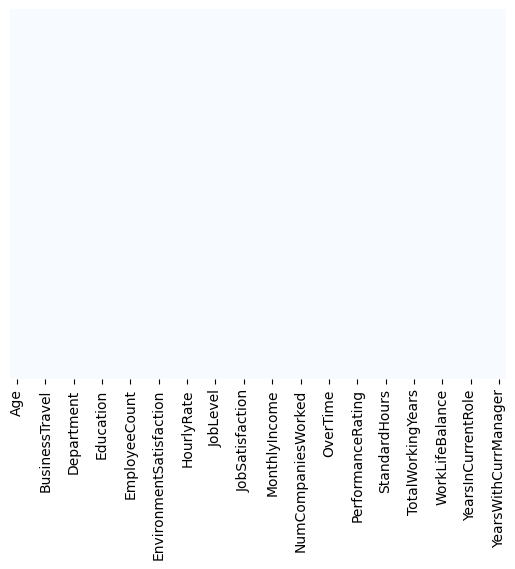

In [270]:
#Lets see if we have any missing data, luckily we dont!
sns.heatmap(employee_df.isnull(), yticklabels = False, cbar = False, cmap ='Blues')

array([[<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Attrition'}>,
        <Axes: title={'center': 'DailyRate'}>,
        <Axes: title={'center': 'DistanceFromHome'}>,
        <Axes: title={'center': 'Education'}>],
       [<Axes: title={'center': 'EmployeeCount'}>,
        <Axes: title={'center': 'EmployeeNumber'}>,
        <Axes: title={'center': 'EnvironmentSatisfaction'}>,
        <Axes: title={'center': 'HourlyRate'}>,
        <Axes: title={'center': 'JobInvolvement'}>],
       [<Axes: title={'center': 'JobLevel'}>,
        <Axes: title={'center': 'JobSatisfaction'}>,
        <Axes: title={'center': 'MonthlyIncome'}>,
        <Axes: title={'center': 'MonthlyRate'}>,
        <Axes: title={'center': 'NumCompaniesWorked'}>],
       [<Axes: title={'center': 'Over18'}>,
        <Axes: title={'center': 'OverTime'}>,
        <Axes: title={'center': 'PercentSalaryHike'}>,
        <Axes: title={'center': 'PerformanceRating'}>,
        <Axes: title={'center': 'Relations

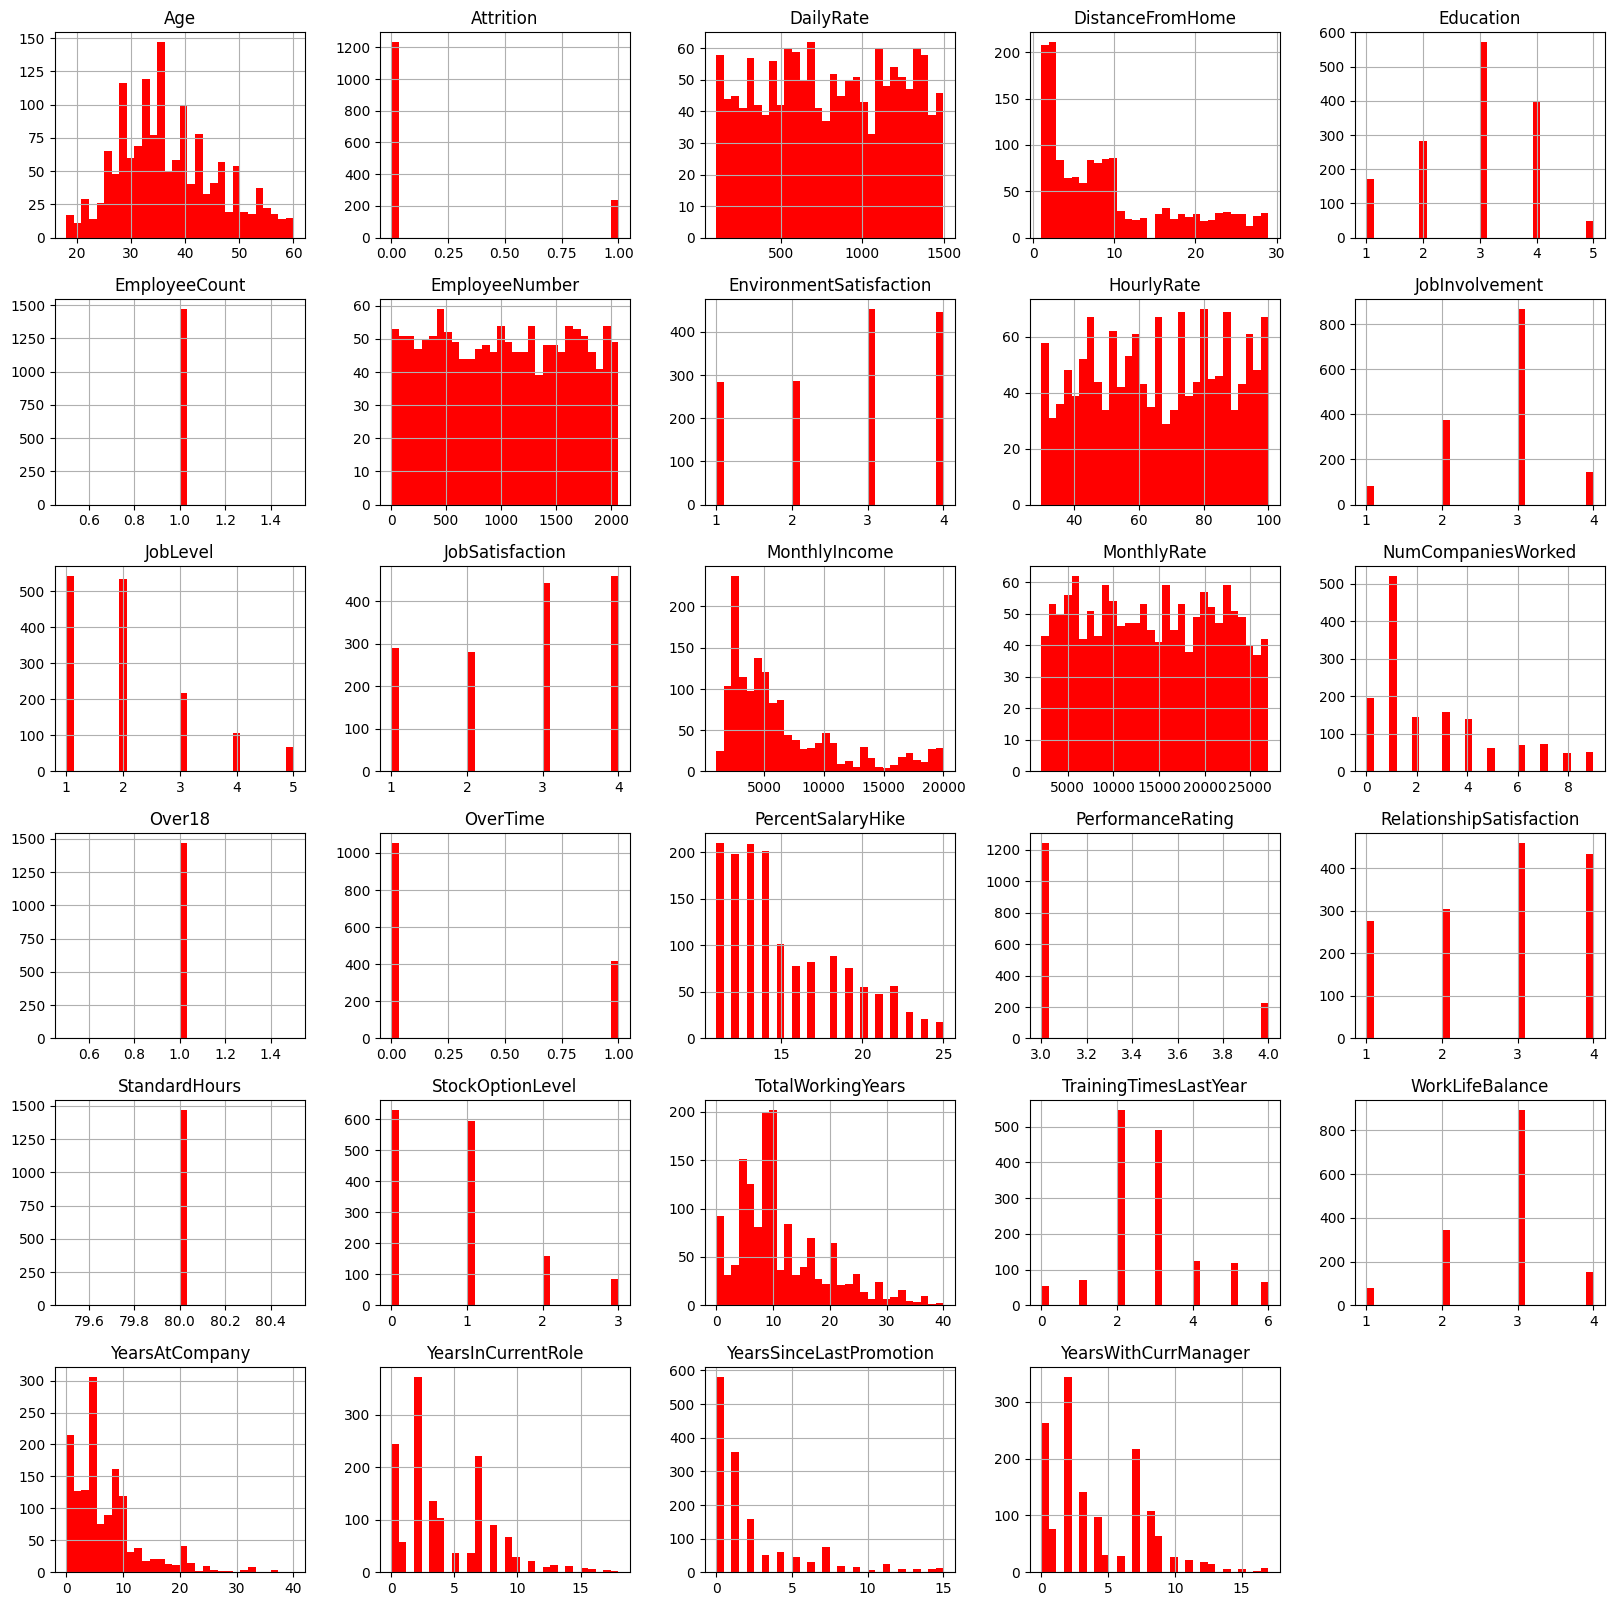

In [271]:
employee_df.hist(bins = 30, figsize = (20,20), color = 'r')
#sevweal feature such as 'MonthlyIncome' and 'TotalWorkingYears' are tail heavy
#It make sense to drop 'EmployeeCount' and 'Standardhpurs' since they do not change from one employee to other

In [272]:
employee_df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,1,1,11,3,1,80,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,1,0,23,4,4,80,1,10,3,3,10,7,1,7
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,1,1,15,3,2,80,0,7,3,3,0,0,0,0
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,1,1,11,3,3,80,0,8,3,3,8,7,3,0
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,1,0,12,3,4,80,1,6,3,3,2,2,2,2


In [273]:
#Tahapan ini dilakukan proses drop kolom yang tidak diperlukan
employee_df.drop(['EmployeeCount','EmployeeNumber','StandardHours','Over18'], axis =1, inplace = True)

In [274]:
employee_df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,1,11,3,1,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,0,23,4,4,1,10,3,3,10,7,1,7
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,1,15,3,2,0,7,3,3,0,0,0,0
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,1,11,3,3,0,8,3,3,8,7,3,0
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,0,12,3,4,1,6,3,3,2,2,2,2
5,32,0,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,4,Male,79,3,1,Laboratory Technician,4,Single,3068,11864,0,0,13,3,3,0,8,2,2,7,7,3,6
6,59,0,Travel_Rarely,1324,Research & Development,3,3,Medical,3,Female,81,4,1,Laboratory Technician,1,Married,2670,9964,4,1,20,4,1,3,12,3,2,1,0,0,0
7,30,0,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,4,Male,67,3,1,Laboratory Technician,3,Divorced,2693,13335,1,0,22,4,2,1,1,2,3,1,0,0,0
8,38,0,Travel_Frequently,216,Research & Development,23,3,Life Sciences,4,Male,44,2,3,Manufacturing Director,3,Single,9526,8787,0,0,21,4,2,0,10,2,3,9,7,1,8
9,36,0,Travel_Rarely,1299,Research & Development,27,3,Medical,3,Male,94,3,2,Healthcare Representative,3,Married,5237,16577,6,0,13,3,2,2,17,3,2,7,7,7,7


In [275]:
employee_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   int64 
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EnvironmentSatisfaction   1470 non-null   int64 
 9   Gender                    1470 non-null   object
 10  HourlyRate                1470 non-null   int64 
 11  JobInvolvement            1470 non-null   int64 
 12  JobLevel                  1470 non-null   int64 
 13  JobRole                   1470 non-null   object
 14  JobSatisfaction         

In [276]:
#kita lihat seberapa banyak karyawan yang tetap tinggal / keluar dari perusahaan!
left_df = employee_df[employee_df['Attrition'] == 1 ]
stay_df = employee_df[employee_df['Attrition'] == 0 ]

In [277]:
#akan kita hitung berapa pekerja/karyawan yang masih tetap stay dan keluar, serta kita hitung berapa persent yang sudah keluar.
#It seems that we are dealing with an imbalanced dataset

print('Total : ',len(employee_df))

print('Number of employee who left : ',len(left_df))
print('% employee who left from company : ',1.*len(left_df)/len(employee_df)*100,'%')

print('Number of employee who stayed : ',len(stay_df))
print('% employee who stayed from company : ',1.*len(stay_df)/len(employee_df)*100,'%')


Total :  1470
Number of employee who left :  237
% employee who left from company :  16.122448979591837 %
Number of employee who stayed :  1233
% employee who stayed from company :  83.87755102040816 %


In [278]:
left_df.describe()

,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,237.000000,237.0,237.000000,237.000000,237.000000,237.000000,237.000000,237.000000,237.000000,237.000000,237.000000,237.000000,237.000000,237.000000,237.000000,237.000000,237.000000,237.000000,237.000000,237.000000,237.000000,237.000000,237.000000,237.000000,237.000000
mean,33.607595,1.0,750.362869,10.632911,2.839662,2.464135,65.573840,2.518987,1.637131,2.468354,4787.092827,14559.308017,2.940928,0.535865,15.097046,3.156118,2.599156,0.527426,8.244726,2.624473,2.658228,5.130802,2.902954,1.945148,2.852321
std,9.689350,0.0,401.899519,8.452525,1.008244,1.169791,20.099958,0.773405,0.940594,1.118058,3640.210367,7208.153264,2.678519,0.499768,3.770294,0.363735,1.125437,0.856361,7.169204,1.254784,0.816453,5.949984,3.174827,3.153077,3.143349
min,18.000000,1.0,103.000000,1.000000,1.000000,1.000000,31.000000,1.000000,1.000000,1.000000,1009.000000,2326.000000,0.000000,0.000000,11.000000,3.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,28.000000,1.0,408.000000,3.000000,2.000000,1.000000,50.000000,2.000000,1.000000,1.000000,2373.000000,8870.000000,1.000000,0.000000,12.000000,3.000000,2.000000,0.000000,3.000000,2.000000,2.000000,1.000000,0.000000,0.000000,0.000000
50%,32.000000,1.0,699.000000,9.000000,3.000000,3.000000,66.000000,3.000000,1.000000,3.000000,3202.000000,14618.000000,1.000000,1.000000,14.000000,3.000000,3.000000,0.000000,7.000000,2.000000,3.000000,3.000000,2.000000,1.000000,2.000000
75%,39.000000,1.0,1092.000000,17.000000,4.000000,4.000000,84.000000,3.000000,2.000000,3.000000,5916.000000,21081.000000,5.000000,1.000000,17.000000,3.000000,4.000000,1.000000,10.000000,3.000000,3.000000,7.000000,4.000000,2.000000,5.000000
max,58.000000,1.0,1496.000000,29.000000,5.000000,4.000000,100.000000,4.000000,5.000000,4.000000,19859.000000,26999.000000,9.000000,1.000000,25.000000,4.000000,4.000000,3.000000,40.000000,6.000000,4.000000,40.000000,15.000000,15.000000,14.000000


In [279]:
stay_df.describe()

,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1233.000000,1233.0,1233.000000,1233.000000,1233.000000,1233.000000,1233.000000,1233.000000,1233.000000,1233.000000,1233.000000,1233.000000,1233.00000,1233.000000,1233.000000,1233.000000,1233.000000,1233.000000,1233.000000,1233.000000,1233.000000,1233.000000,1233.000000,1233.000000,1233.000000
mean,37.561233,0.0,812.504461,8.915653,2.927007,2.771290,65.952149,2.770479,2.145985,2.778589,6832.739659,14265.779400,2.64558,0.234388,15.231144,3.153285,2.733982,0.845093,11.862936,2.832928,2.781022,7.369019,4.484185,2.234388,4.367397
std,8.888360,0.0,403.208379,8.012633,1.027002,1.071132,20.380754,0.692050,1.117933,1.093277,4818.208001,7102.260749,2.46009,0.423787,3.639511,0.360408,1.071603,0.841985,7.760719,1.293585,0.681907,6.096298,3.649402,3.234762,3.594116
min,18.000000,0.0,102.000000,1.000000,1.000000,1.000000,30.000000,1.000000,1.000000,1.000000,1051.000000,2094.000000,0.00000,0.000000,11.000000,3.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,31.000000,0.0,477.000000,2.000000,2.000000,2.000000,48.000000,2.000000,1.000000,2.000000,3211.000000,7973.000000,1.00000,0.000000,12.000000,3.000000,2.000000,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,0.0,817.000000,7.000000,3.000000,3.000000,66.000000,3.000000,2.000000,3.000000,5204.000000,14120.000000,2.00000,0.000000,14.000000,3.000000,3.000000,1.000000,10.000000,3.000000,3.000000,6.000000,3.000000,1.000000,3.000000
75%,43.000000,0.0,1176.000000,13.000000,4.000000,4.000000,83.000000,3.000000,3.000000,4.000000,8834.000000,20364.000000,4.00000,0.000000,18.000000,3.000000,4.000000,1.000000,16.000000,3.000000,3.000000,10.000000,7.000000,3.000000,7.000000
max,60.000000,0.0,1499.000000,29.000000,5.000000,4.000000,100.000000,4.000000,5.000000,4.000000,19999.000000,26997.000000,9.00000,1.000000,25.000000,4.000000,4.000000,3.000000,38.000000,6.000000,4.000000,37.000000,18.000000,15.000000,17.000000


Berdasarkan describe kedua tabel diatas (Left & Stayed) dapat dilihat bahwa,

* Usia rata-rata pegawai yang stay lebih muda ketimbang yang left,
* Nilai STD (standard deviasi) lebih rendah karyawan yang masih stay
* Gaji (DailyRate) rata2 karyawan stayed itu lebih besar
* Jarak (DistanceFromHome) rata2 rumah karyawan yg left dg yg stayed itu lebih jauh yang left
* EnvironmentSatisfaction & JobStatisfaction : Kepuasan Lingkungan kerja yg stayed juga lebih besar
* StockOptionLevel :Tingkat opsi saham pun yg paling terawat juga dari yg stay

#2. Visual Explore Dataset

<Axes: >

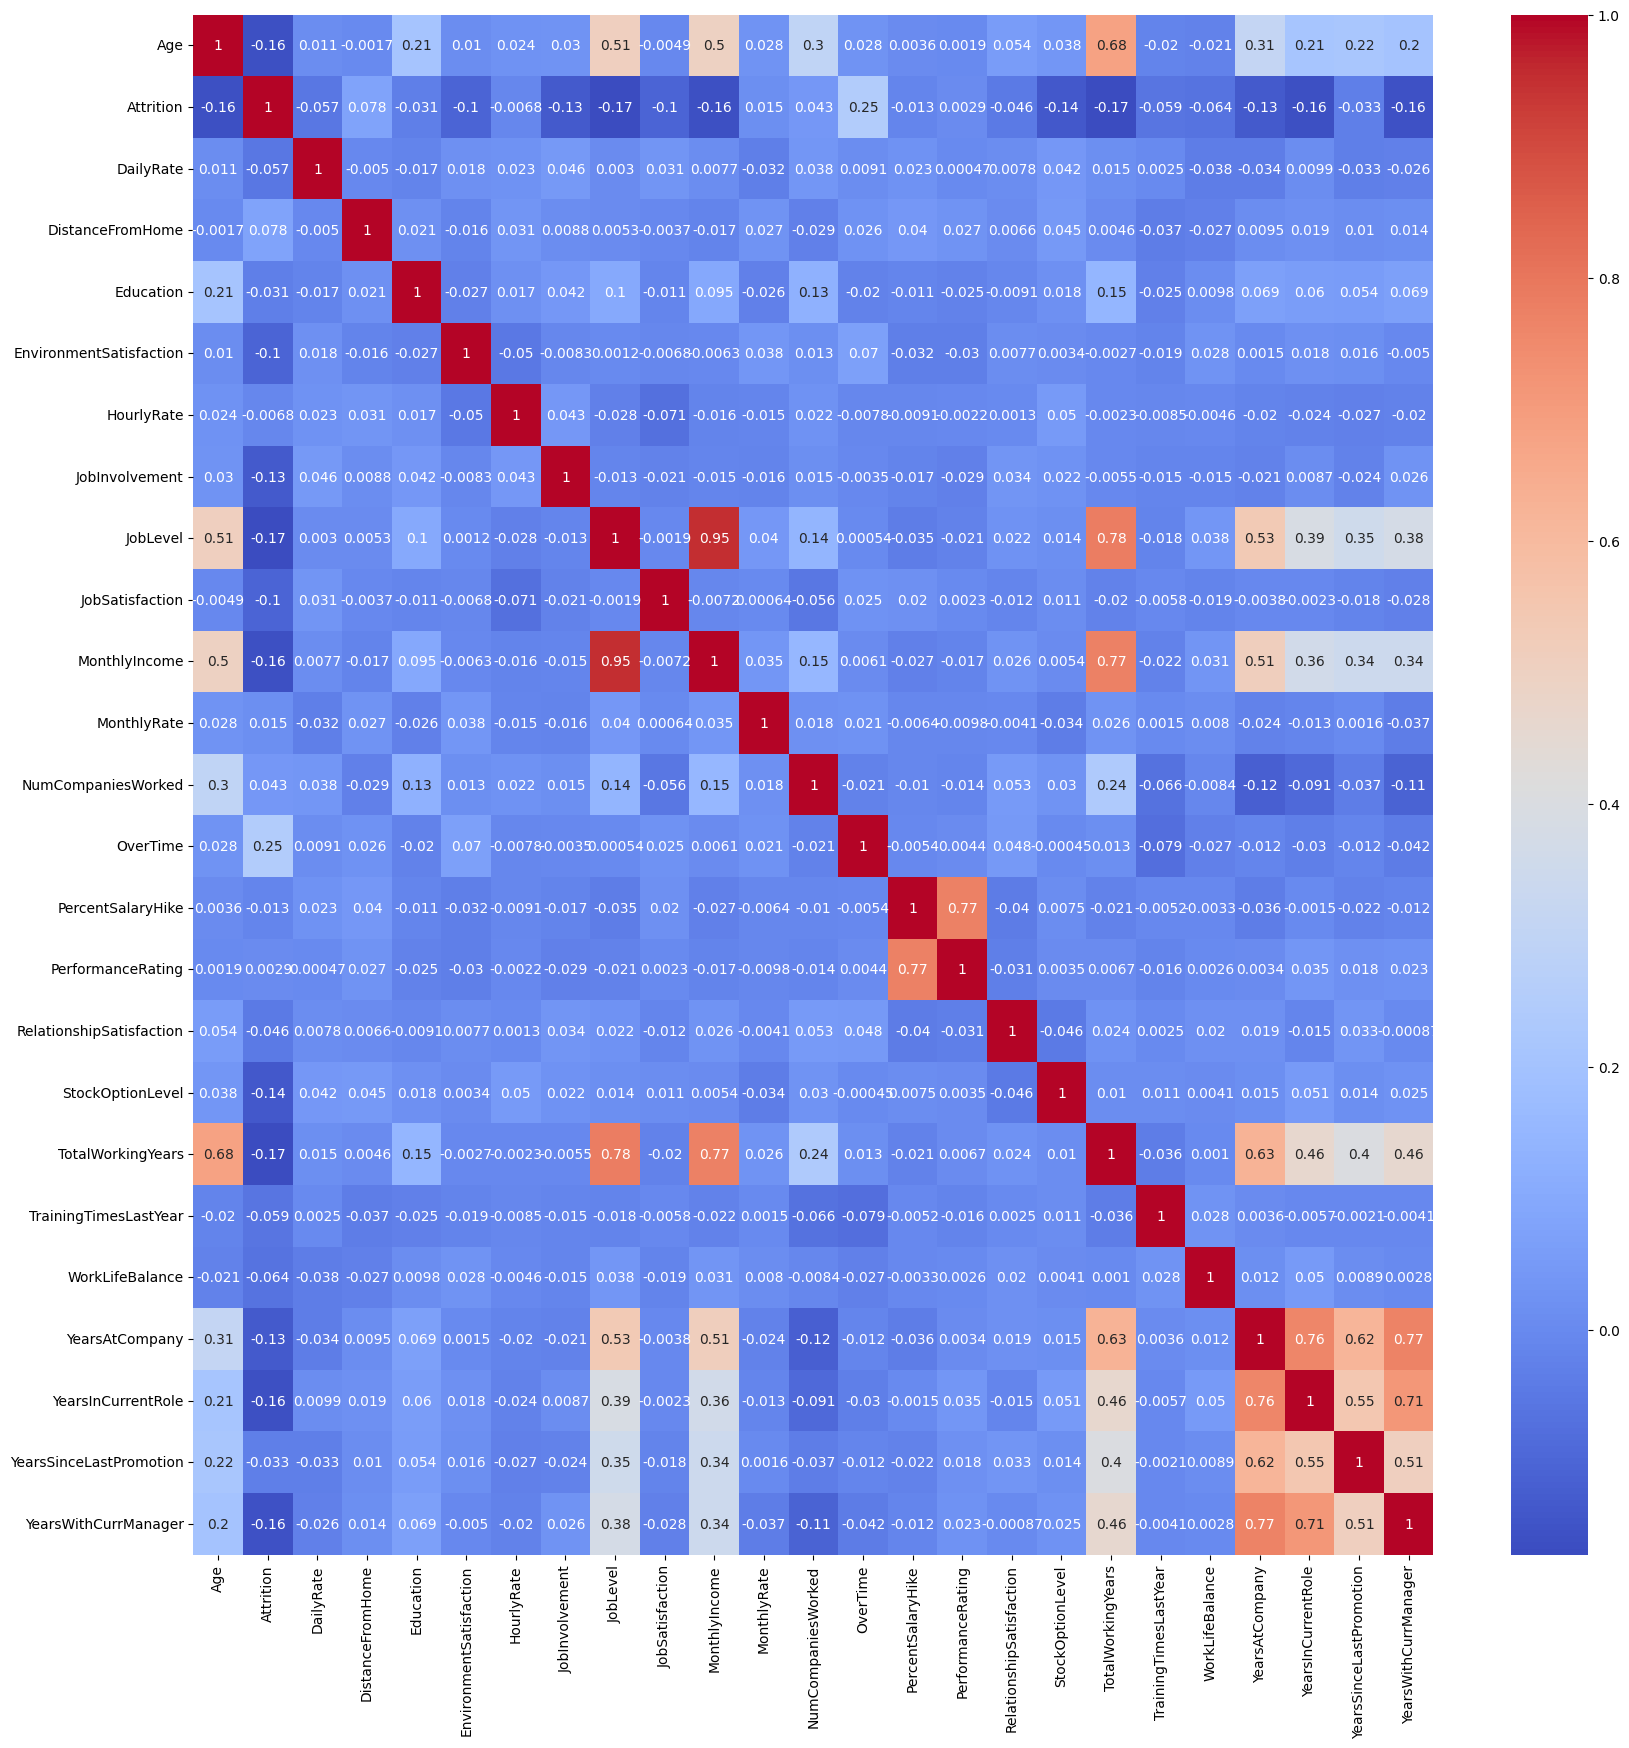

In [280]:
correlations = employee_df.corr(numeric_only=True)
f, ax = plt.subplots(figsize=(20,20))
sns.heatmap(correlations, annot = True, cmap ='coolwarm')

#Joblevel is strongly correlated with TotalWorkingHours
#MonthlyIncome is strongly correlated with JobLevel
#MonthlyIncome is strongly correlated with TotalWorkingHours
#Age is strongly correlated with MonthlyMncome

**Berdasarkan Heatmap diatas terlihat bahwa,**
* MonthlyIncome-JobLevel : nilai korelasi 0.95. Artinya penghasilanya sangat besar, menunjukkan makin tinggi jabatan semakin tinggi pula penghasilannya.
* MonthlyIncome-TotalWorkingYears : nilai korelasi 0.78. Artinya semakin lama pegawai itu bekerja, maka nilai salarynya juga semakin besar
* Joblevel-TotalWorkingYears : nilai korelasinya 0.77. Artinya jabatan meningkat seiring lama pengalaman kerja.
* Age-Attrition : nilai korelasi negati -0.16 Artinya, semakin tua karyawan cenderung lebih kecil kemungkinan untuk keluar (Attrition)
* Nilai korelasinya negatif, menunjukkan hubungannya lemah tapi logis.



<Axes: xlabel='Age', ylabel='count'>

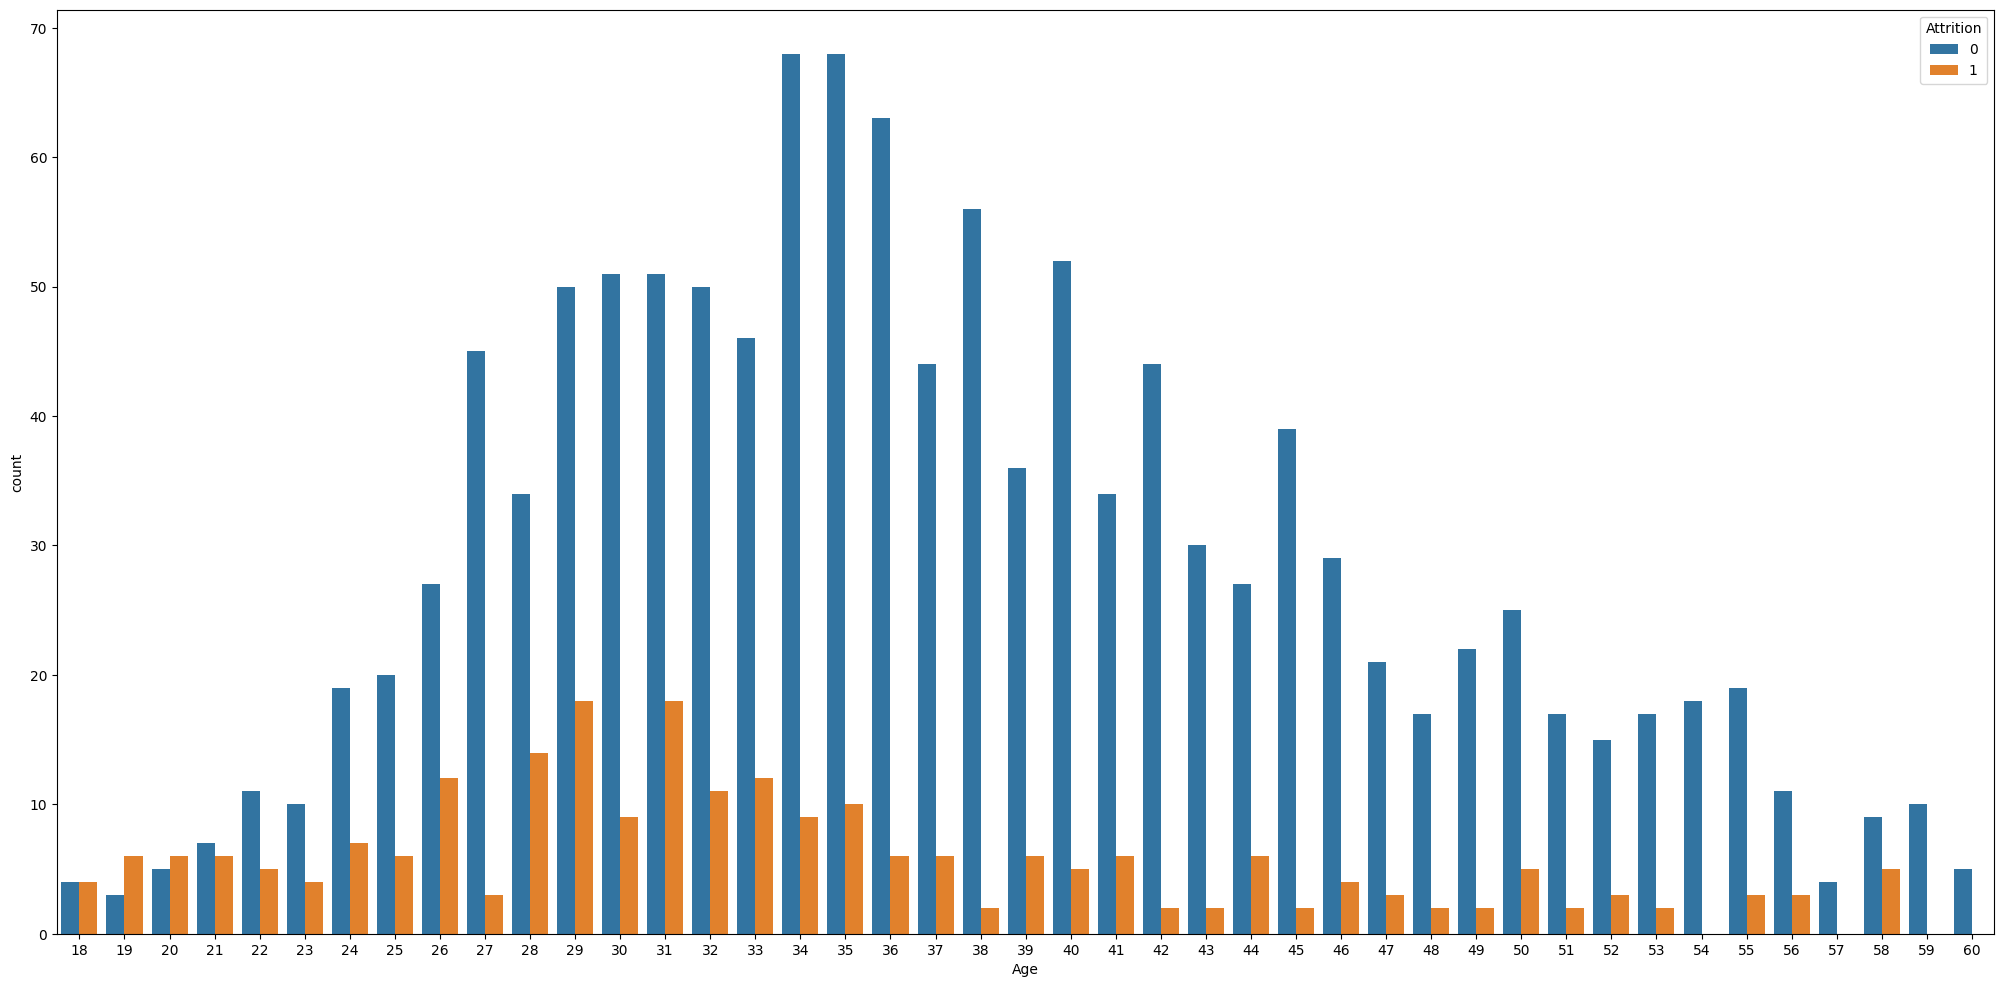

In [281]:
plt.figure(figsize=[25,12])
sns.countplot(x='Age', hue='Attrition', data = employee_df)

<Axes: xlabel='JobLevel', ylabel='count'>

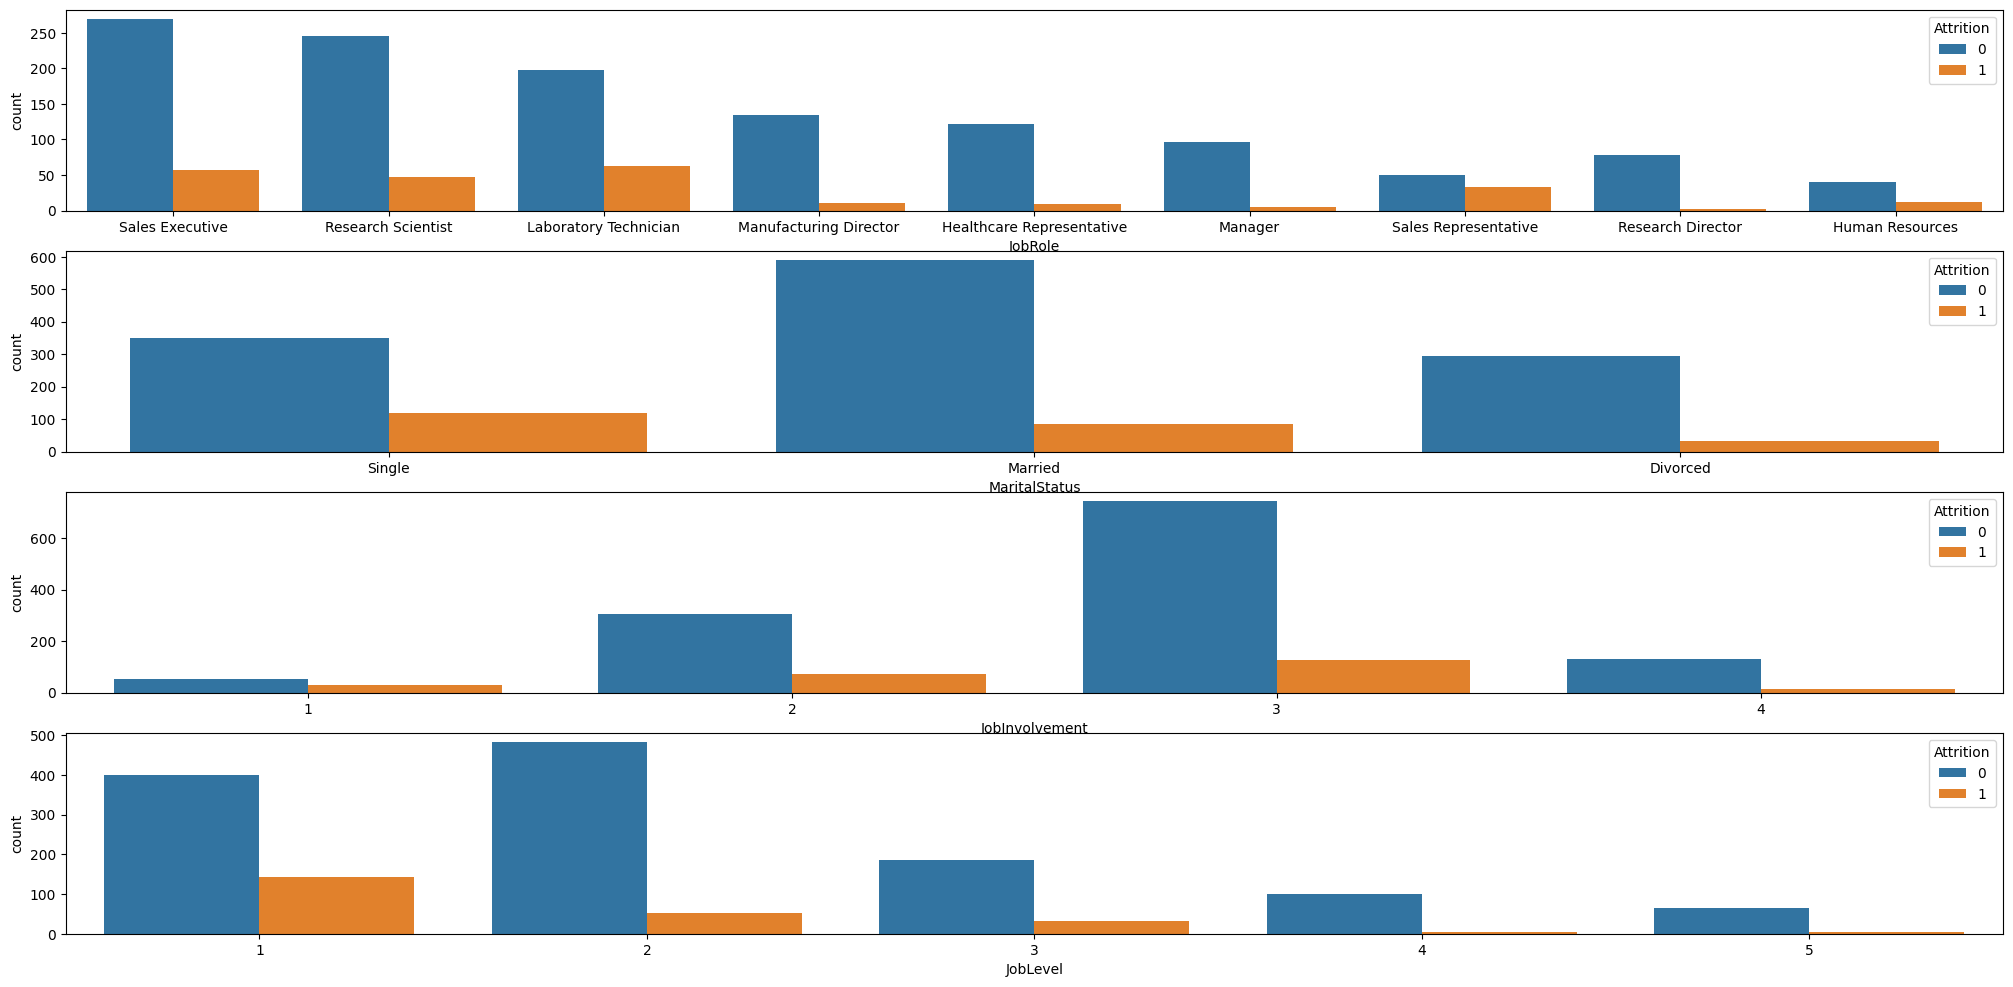

In [282]:
#Single employees tend to leave compared to married and divorced
#Sales Representitives tend to leave compared to any other job
#Less involved employees tend to leave the company
#Less experienced (low job level) tend to leave the company

plt.figure(figsize=[25,12])

plt.subplot(411)
sns.countplot(x='JobRole', hue='Attrition', data = employee_df)

plt.subplot(412)
sns.countplot(x='MaritalStatus', hue='Attrition', data = employee_df)

plt.subplot(413)
sns.countplot(x='JobInvolvement', hue='Attrition', data = employee_df)

plt.subplot(414)
sns.countplot(x='JobLevel', hue='Attrition', data = employee_df)

/tmp/ipykernel_4808/2859432399.py:5: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(left_df['DistanceFromHome'], label = 'Employee Who left', shade =True, color = 'r')
/tmp/ipykernel_4808/2859432399.py:6: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(stay_df['DistanceFromHome'], label = 'Employee Who stay', shade =True, color = 'b')


<Axes: xlabel='DistanceFromHome', ylabel='Density'>

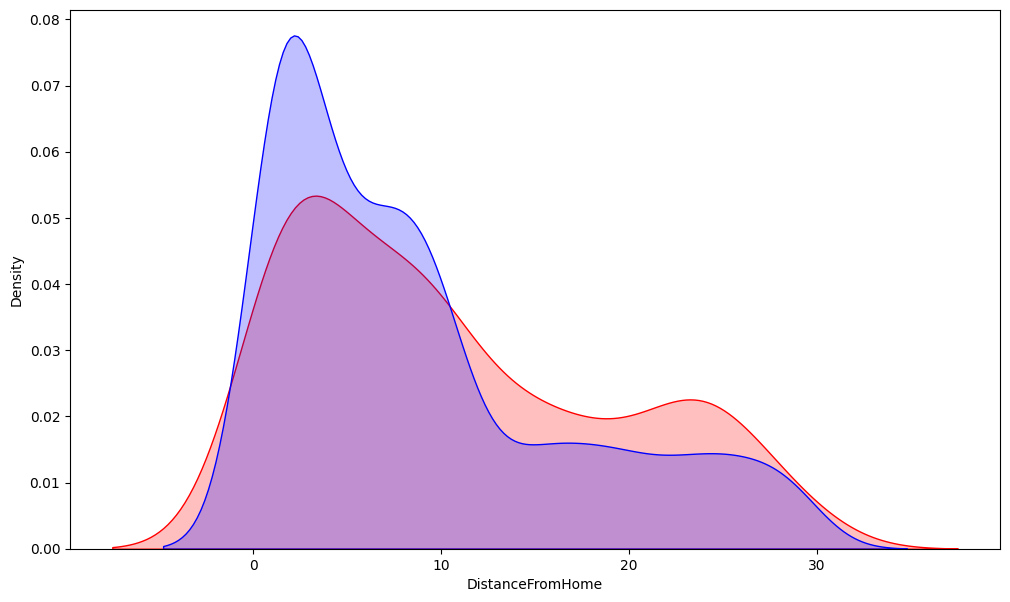

In [283]:
#KDE (Kernel Density Estimate) is used for visualizing the probability density of continures variable
#KDE Describe the probability density at different values in a continuous variable.

plt.figure(figsize =(12,7))
sns.kdeplot(left_df['DistanceFromHome'], label = 'Employee Who left', shade =True, color = 'r')
sns.kdeplot(stay_df['DistanceFromHome'], label = 'Employee Who stay', shade =True, color = 'b')

/tmp/ipykernel_4808/2819464818.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(left_df['YearsWithCurrManager'], label = 'Employee Who left', shade =True, color = 'r')
/tmp/ipykernel_4808/2819464818.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(stay_df['YearsWithCurrManager'], label = 'Employee Who stay', shade =True, color = 'b')


Text(0.5, 0, 'YearsWithCurrManager')

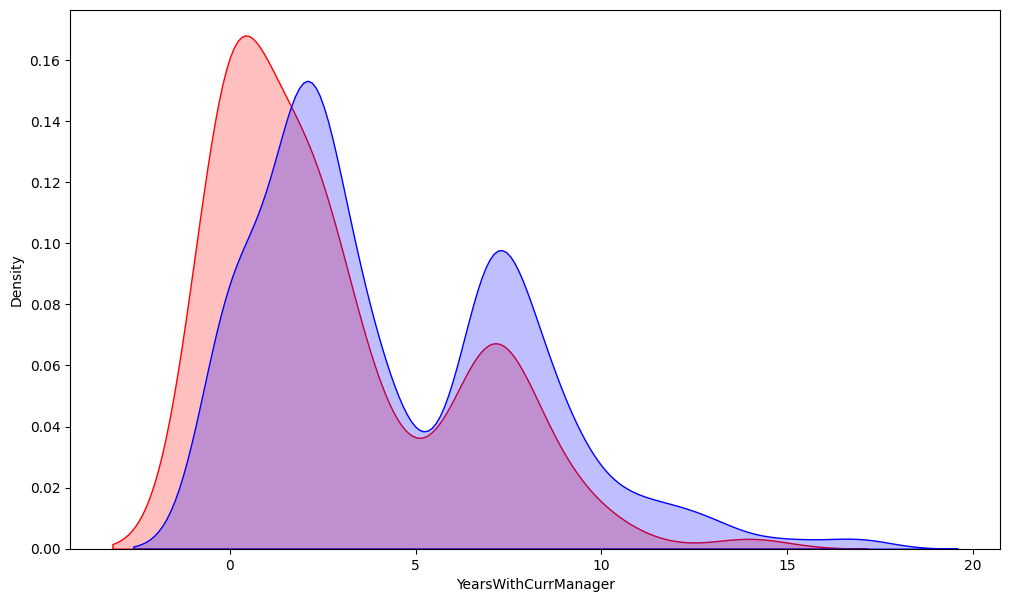

In [284]:
plt.figure(figsize = (12,7))
sns.kdeplot(left_df['YearsWithCurrManager'], label = 'Employee Who left', shade =True, color = 'r')
sns.kdeplot(stay_df['YearsWithCurrManager'], label = 'Employee Who stay', shade =True, color = 'b')

plt.xlabel('YearsWithCurrManager')

###Berdasarkan plot kde diatas terlihat,
(red = left ; blue = stayed)

* Terlihat keduanya sama-sama memiliki puncak.
* Red :
> Puncak tertinggi di 0-2 Tahun, Artinya sebagian besar karyawan yang keluar belum lama bekerja dengan manager mereka.
> Setelah 5 tahun keatas, tidak banyak yang keluar, artinya sudah lama bekerja dengan manager mereka sangat jarang yang keluar
* Blue :
> Puncak pertama di 2-3 tahun (ada sedikir overlap dengan red), masih banyak yang stay dengan manager mereka meskipun ditahun2 awal.
> Ada puncak kedua di tahun ke 8-10. Mereka sudah lama bersama dengan manager mereka dan tetap bertahan\



/tmp/ipykernel_4808/1692679760.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(left_df['TotalWorkingYears'], label = 'Employee Who left', shade =True, color = 'r')
/tmp/ipykernel_4808/1692679760.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(stay_df['TotalWorkingYears'], label = 'Employee Who stay', shade =True, color = 'b')


Text(0.5, 0, 'TotalWorkingYears')

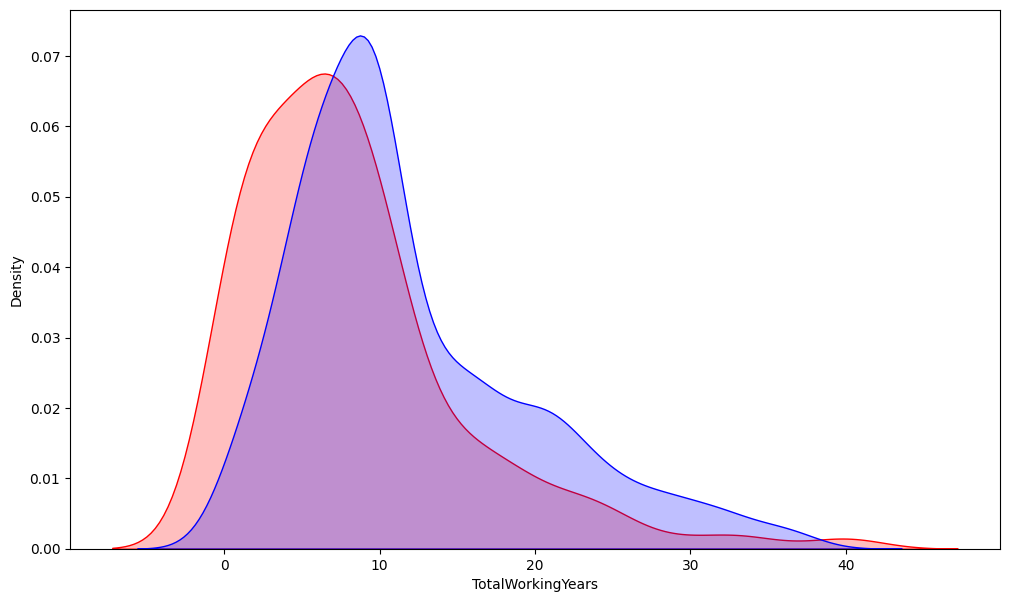

In [285]:
plt.figure(figsize = (12,7))
sns.kdeplot(left_df['TotalWorkingYears'], label = 'Employee Who left', shade =True, color = 'r')
sns.kdeplot(stay_df['TotalWorkingYears'], label = 'Employee Who stay', shade =True, color = 'b')

plt.xlabel('TotalWorkingYears')

<Axes: xlabel='MonthlyIncome', ylabel='Gender'>

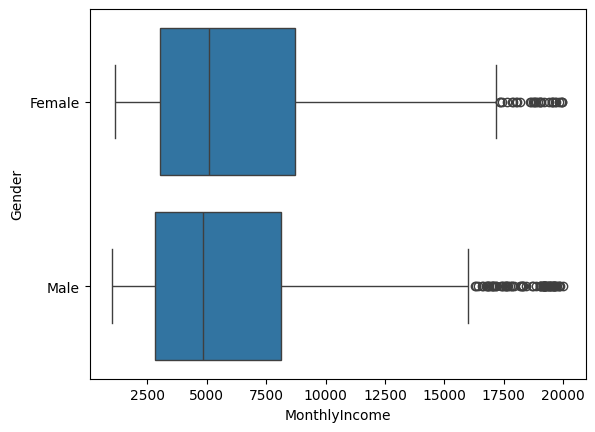

In [286]:
#lets see the gender vs monthlyIncome
sns.boxplot(x = 'MonthlyIncome', y = 'Gender', data = employee_df)

<Axes: xlabel='MonthlyIncome', ylabel='JobRole'>

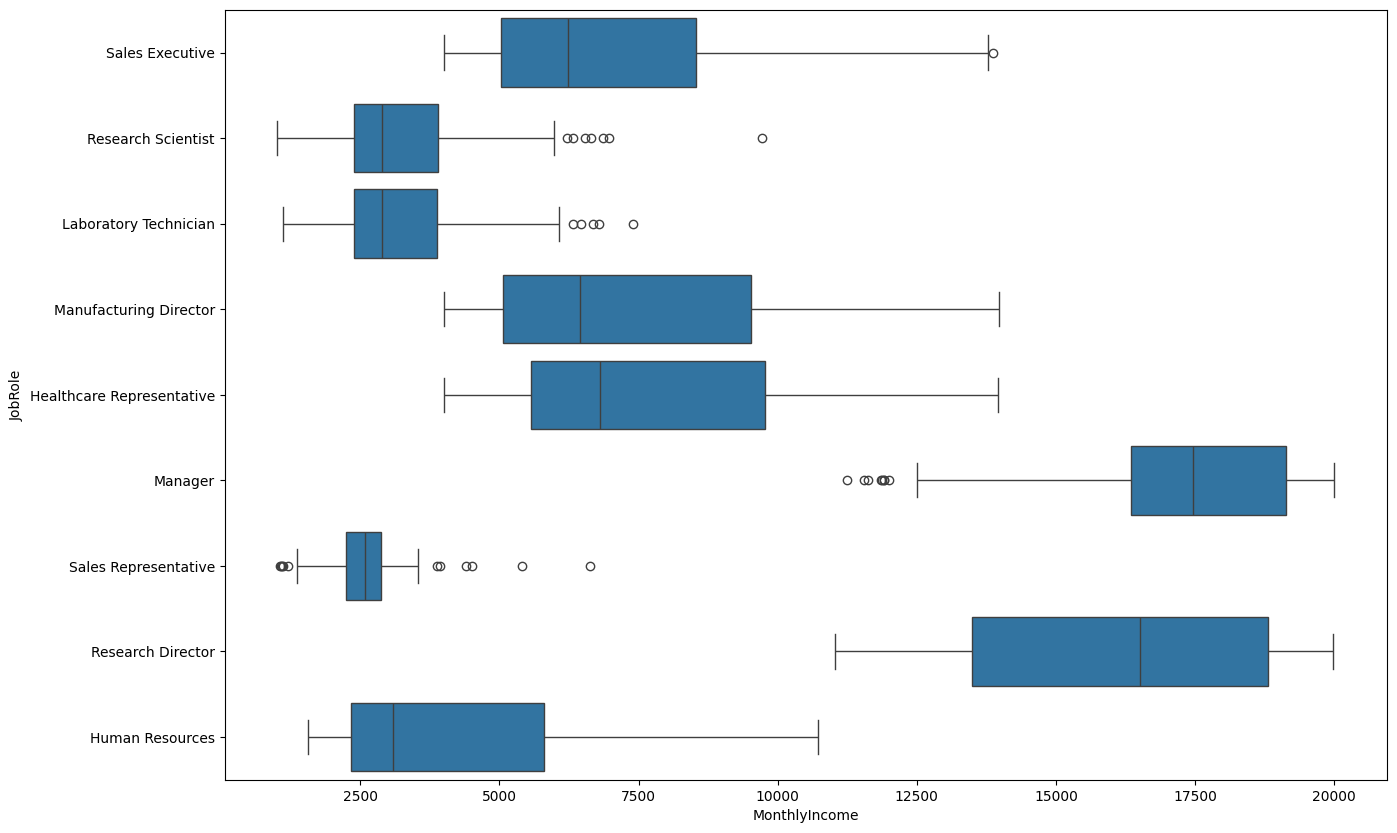

In [287]:
#lets see the Job Role vs Monthly Income
plt.figure(figsize = (15,10))
sns.boxplot(x = 'MonthlyIncome', y = 'JobRole', data = employee_df)

###Dari boxplot diatas, terlihat bahwa terdapat dua top earners yaitu :
Manager & Research Director (RD)
* Manager memiliki pendapatan tertinggi diantara semua department
* Median (garis box) Manager = sekitar 17.500
* Manager memiliki outlier, artinya masih banyak MGR yang memiliki gaji yang jauh dari nilai minimum (12.500)
* Median (garis box) Research Director = sekitar 17.000
* Akan tetapi,
> RD memiliki persebaran data yang cukup panjang. Yaitu min sekitar 10.500-13.000. Serta memiliki rentang antar Quartil atau Interquartil Range (IQR) sekitar 13.000-18.000.
* Persebaran data RD yang cukup panjang atau jauh inilah yang menunjukan bahwa RD memiliki variasi penghasilan tinggi dan cukup konsisten dan stabil.
* Artinya gaji tinggi yang dimiliki tim RD bukan cuma satu dua orang,tapi memang banyak yang berada direantang atas (13.000-18.000)


#3. Data Cleaning

In [288]:
employee_df.head(3)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,1,11,3,1,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,0,23,4,4,1,10,3,3,10,7,1,7
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,1,15,3,2,0,7,3,3,0,0,0,0


**Proses pemisahanan target (label) dan fitur (variabel prediksi),**

* y --> berisikan kolom target (dalam kasus ini : apakah pegawai keluar = 1, atau tetap = 0
* x --> berisi semua variabel independen yg digunakan u/ meprediksi y
* axis = 1 --> artinya drop kolom berdasarkan kolom (bukan baris)


In [289]:
# 1.Pisahkan target y dari x
y = employee_df['Attrition']
X = employee_df.drop('Attrition', axis = 1)

In [290]:
# 2.Pisahkan kolom kategorikal & numerik
X_cat = X.select_dtypes(include='object')
X_numerical = X.select_dtypes(exclude='object')

In [291]:
X_cat

,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus
0,Travel_Rarely,Sales,Life Sciences,Female,Sales Executive,Single
1,Travel_Frequently,Research & Development,Life Sciences,Male,Research Scientist,Married
2,Travel_Rarely,Research & Development,Other,Male,Laboratory Technician,Single
3,Travel_Frequently,Research & Development,Life Sciences,Female,Research Scientist,Married
4,Travel_Rarely,Research & Development,Medical,Male,Laboratory Technician,Married
...,...,...,...,...,...,...
1465,Travel_Frequently,Research & Development,Medical,Male,Laboratory Technician,Married
1466,Travel_Rarely,Research & Development,Medical,Male,Healthcare Representative,Married
1467,Travel_Rarely,Research & Development,Life Sciences,Male,Manufacturing Director,Married
1468,Travel_Frequently,Sales,Medical,Male,Sales Executive,Married


In [292]:
X_numerical

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1102,1,2,2,94,3,2,4,5993,19479,8,1,11,3,1,0,8,0,1,6,4,0,5
1,49,279,8,1,3,61,2,2,2,5130,24907,1,0,23,4,4,1,10,3,3,10,7,1,7
2,37,1373,2,2,4,92,2,1,3,2090,2396,6,1,15,3,2,0,7,3,3,0,0,0,0
3,33,1392,3,4,4,56,3,1,3,2909,23159,1,1,11,3,3,0,8,3,3,8,7,3,0
4,27,591,2,1,1,40,3,1,2,3468,16632,9,0,12,3,4,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,884,23,2,3,41,4,2,4,2571,12290,4,0,17,3,3,1,17,3,3,5,2,0,3
1466,39,613,6,1,4,42,2,3,1,9991,21457,4,0,15,3,1,1,9,5,3,7,7,1,7
1467,27,155,4,3,2,87,4,2,2,6142,5174,1,1,20,4,2,1,6,0,3,6,2,0,3
1468,49,1023,2,3,4,63,2,2,2,5390,13243,2,0,14,3,4,0,17,3,2,9,6,0,8


In [293]:
# 3.One-hot encoding untuk kolom katagorikal
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore') #onehotencoder --> mengubah kategori menjadi 0/1, output numpy.ndarray
X_cat_array = encoder.fit_transform(X_cat)

In [294]:
# 4.Gabungkan hasil encode + kolom numerik
X_all = np.concatenate([X_cat_array, X_numerical.values], axis=1)
#X_all --> siap training

In [295]:
X_all

array([[0., 0., 1., ..., 4., 0., 5.],
       [0., 1., 0., ..., 7., 1., 7.],
       [0., 0., 1., ..., 0., 0., 0.],
       ...,
       [0., 0., 1., ..., 2., 0., 3.],
       [0., 1., 0., ..., 6., 0., 8.],
       [0., 0., 1., ..., 3., 1., 2.]])

In [296]:
X_cat_array.shape

(1470, 26)

In [297]:
print(type(X_all),X_all.shape)

<class 'numpy.ndarray'> (1470, 50)


### **Proses Split Data**
memisahkan dataset menjadi,
* X_train >> fiture u/ training (75%)
* X_test >> fiture u/ pengujian (25%)
* y_train >> target (Attrition) untuk training
* y_test >> target untuk testing

In [298]:
# 5.Split data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.25, random_state=42, stratify=y
)

#4. Train & Evaluate Logistic Regression

**Proses Scaling atau Normalisasi**
diamana kita akan men-scale semua fitur (karena gabungan numerik + one-hot bisa punya rentang nilai yang berbeda

In [299]:
from sklearn.preprocessing import MinMaxScaler

# 6.Normalisasi / Scaling
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [300]:
print("Distribusi di y_train:")
print(y_train.value_counts())

print("\nDistribusi di y_test:")
print(y_test.value_counts())

Distribusi di y_train:
Attrition
0    924
1    178
Name: count, dtype: int64

Distribusi di y_test:
Attrition
0    309
1     59
Name: count, dtype: int64


In [301]:
employee_df['Attrition'].value_counts()

,count
Attrition,
0,1233
1,237


**Train Model Logistic Regression**

In [302]:
# 7. Model Logistic Regression
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000) #max_iter = 1000 agar proses training cukup iterasi konvergen
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

**Evaluasi Model**

In [303]:
# 8. Evaluasi Model
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [304]:
y_pred = model.predict(X_test)

In [305]:
print("Akurasi:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Akurasi: 0.8722826086956522

Confusion Matrix:
 [[300   9]
 [ 38  21]]

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.97      0.93       309
           1       0.70      0.36      0.47        59

    accuracy                           0.87       368
   macro avg       0.79      0.66      0.70       368
weighted avg       0.86      0.87      0.85       368



In [306]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred) #>> menghitung rasio prediksi yang benar dibanding total uji data
print(f"Akurasi model: {accuracy * 100:.2f}%") # :.2f artinya tampilkan dua angka dibelakang koma (misal 84.50%)

Akurasi model: 87.23%


<Axes: >

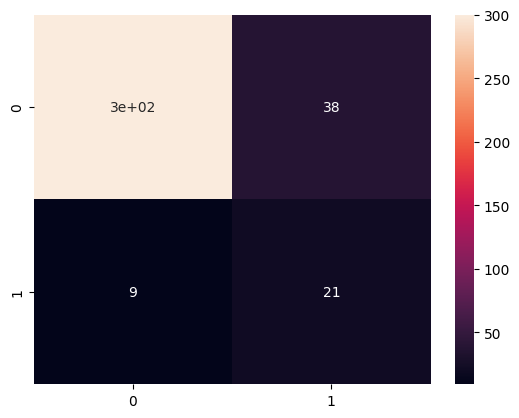

In [307]:
cm = confusion_matrix(y_pred, y_test)
sns.heatmap(cm, annot = True)

In [308]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.89      0.97      0.93       309
           1       0.70      0.36      0.47        59

    accuracy                           0.87       368
   macro avg       0.79      0.66      0.70       368
weighted avg       0.86      0.87      0.85       368



# 5. Train & Evaluate A Random Forest Classification

In [309]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

In [310]:
y_pred = model.predict(X_test)

<Axes: >

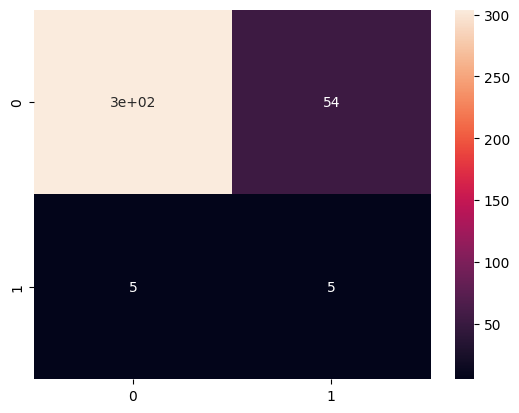

In [311]:
#Test set performance
cm = confusion_matrix(y_pred, y_test)
sns.heatmap(cm, annot = True)

In [312]:
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Confusion Matrix:
 [[304   5]
 [ 54   5]]

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.98      0.91       309
           1       0.50      0.08      0.14        59

    accuracy                           0.84       368
   macro avg       0.67      0.53      0.53       368
weighted avg       0.79      0.84      0.79       368



#6. Train & Evaluate a Deep Learning Model

In [353]:
import tensorflow as tf
#tensorflow adalah framework deeplearning opensource buatan google dirancang u/ membuat&mlatih jaringan saraf  tiruan.

model = tf.keras.models.Sequential() #keras adl cara cepat simpel u/ pakai tensorflow
model.add(tf.keras.layers.Dense(units = 500, activation = 'relu', input_shape = (50,)))
model.add(tf.keras.layers.Dense(units = 500, activation = 'relu'))
model.add(tf.keras.layers.Dense(units = 500, activation = 'relu'))
model.add(tf.keras.layers.Dense(units = 1, activation = 'sigmoid'))

#hubungan antara tensorflow dg keras :
#TF = seperti dapur lengkap dg semua alat canggih (oven besar, mixer industri, timbangan presisi)
#keras = alat dapur otomatis utk mempermudah kita bikin kue tanpa ribet. tinggal tombol bebrapa doang
#jadi, kesimpulannya = TF adalah mesin utama deeplearning, sdgkn keras adalah cara mudah u/ ngobrol dg TF


In [354]:
model.summary()

Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_63 (Dense)                │ (None, 500)            │        25,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 500)            │       250,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_65 (Dense)                │ (None, 500)            │       250,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_66 (Dense)                │ (None, 1)              │           501 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 527,001 (2.01 MB)

 Trainable params: 527,001 (2.01 MB)

 Non-trainable params: 0 (0.00 B)

###Bagaimana Deeplearning itu bekerja?
##### Deep Learning itu memakai lapisan-lapisan neuron (nodes) yang saling terhubung. Makanya, disebut deep -->karna punya banyak layers tersembunyi (hidden layers) antara input dan output
misal :
* Input (gambar kucing)
* → Hidden Layer 1 (deteksi tepi)
* → Hidden Layer 2 (deteksi bentuk)
* → Hidden Layer 3 (deteksi wajah kucing)
* → Output: "Ini kucing"

### Penjelasan Summary Model TF DeepLearning
######1. Layer(type) = jenis layer yang dipakai semuanya 'Dense'. Artinya Fully Connected Layer --> setiap neuron saling terhubung ke semua neuron di layer sebelumnya
#####2. Output Shape
* (None,500) artinya output dari layer berukuran vektor 500
* None, berarti jumlah sampel (batch size) belum ditentukan --> fleksible tergantung saat training nanti
*  (None,1) dilayer terakhir berarti output cuma 1 nilai --> biasanya biner (misalnya yes/no, 1/0)
#####3. Param (Jumlah Parameter)
* ini menunjukkan bebrapa banyak nilai (weight + bias) yang harus dipelajari model layer.
* Cara hitungnya, Jumlah parameter = (jml neuron input x neuron output)+ neuron output(bias)

Contoh dense_13 -->
* input 50 neuron (misal input_shape=(50,))
* output 500 neuron
* param = (50x500)+500 = 25,500

Contoh dense_14 -->
* input 500 neuron
* output 500 neuron
* param = (500x500)+500 = 250,500

#####4.Total Parameter = ada 527.001 parameter total yg harus dipelajari (disesuaikan saat training) dan semuanya bisa dilatih (trainable). ukurannya disimpan sekitar 2.01 MB




In [350]:
#Menyiapkan model sebelum mulai dilatih (fit())
model.compile(optimizer='Adam', loss ='binary_crossentropy', metrics = ['accuracy'])
#langkah compilenya ada 3, optimizer (memperbarui bobot)-loss function(seberapa salah prediksi model)-metrics(cara mengukur performa model)

In [356]:
#Proses ini inti dari DeepLearning
#Training atau Pelatihan model.
epochs_hist = model.fit(X_train, y_train, epochs = 100, batch_size = 50)

ValueError: You must call `compile()` before using the model.

In [355]:
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


In [357]:
y_pred

array([[False],
       [ True],
       [False],
       [ True],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [ True],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [ True],
       [ True],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [

In [ ]:
plt.plot (epochs_hist.history['loss'])
plt.title ('Model Loss Progress During Training')
plt.xlabel('Epoch')
plt.ylabel ('Training Loss')
plt.legend (['Training Loss'])

dari hasil plot Training Loss diatas,
* Di awal epoch (0-10) loss masih tinggi sekitar 0.4-0.1
* Setelah sekitar epoch ke-20, loss mendekati 0 dan stabil hingga akhir training
* Ini artinya, model belajar dengan sangat baik terhadap data training, bahkan mungkin ini terlalu baik ^^'

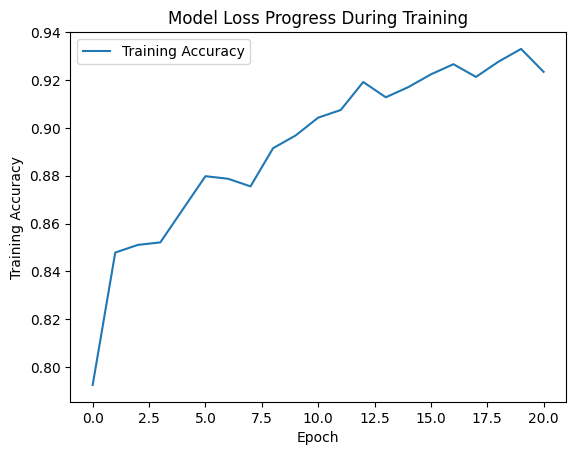

In [358]:
plt.plot (epochs_hist.history['accuracy'])
plt.title ('Model Loss Progress During Training')
plt.xlabel('Epoch')
plt.ylabel ('Training Accuracy')
plt.legend (['Training Accuracy'])

<Axes: >

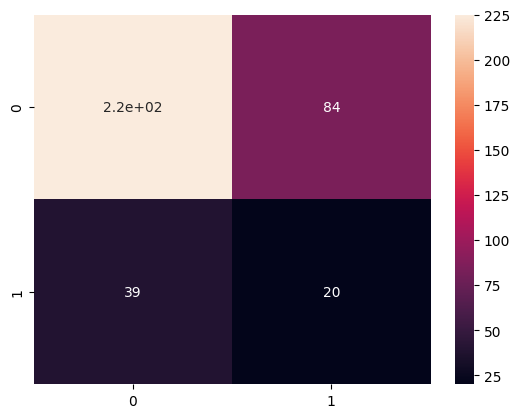

In [359]:
cm = confusion_matrix(y_test,y_pred)
sns.heatmap(cm, annot = True)

In [360]:
print (classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.85      0.73      0.79       309
           1       0.19      0.34      0.25        59

    accuracy                           0.67       368
   macro avg       0.52      0.53      0.52       368
weighted avg       0.75      0.67      0.70       368



#7. Memperbaiki Overfitting

dikarenakan percobaan dari mechine lerning sebelumnya terlihat bagus atau sempurna saat di training data,akan tapi sebenernya dia cukup jelek didata baru (validation/test data nya). Dengan kata lain, model 'hafal'datanya, bukan 'mengerti polanya'.

Ciri-ciri grafiknya,
* Training loss / accuracynya : sangat bagus (loss -->0, accuracy --> 100%
* Validation loss / accuracynya : mulai memburuk setelah beberpa epoch. jadi model terlihat 'hebat' padahal sebenrenya cuma hafal data yg sudah dilihat.

Hal inilah yang dinamakan overfitting dalam model.

Tujuan utama Mechine Learning ialah,
membuat model yg tdk hanya bagus di training, tapi juga bagus didata yang belum pernah dilihat. atau yg disebut dengan generalization.

Oleh karna itu kita lakukan perbaikan overfittingnya sbb,

In [373]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [374]:
# 2️⃣ Split data (contoh)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

**One-Hot Encode Categorical Features**

In [375]:
# Separate categorical and numerical features
X_cat = X.select_dtypes(include='object')
X_numerical = X.select_dtypes(exclude='object')

# One-hot encode categorical features
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_cat_encoded = encoder.fit_transform(X_cat)

# Convert the encoded categorical features back to a DataFrame with appropriate column names
# We need to get the feature names after encoding
encoded_feature_names = encoder.get_feature_names_out(X_cat.columns)
X_cat_encoded_df = pd.DataFrame(X_cat_encoded, columns=encoded_feature_names, index=X.index)

# Concatenate the encoded categorical features and the numerical features
X_processed = pd.concat([X_cat_encoded_df, X_numerical], axis=1)

**Split Data after Encoding and Scale**

In [376]:
# Split the data into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.2, random_state=42, stratify=y
)

# Normalisasi fitur (penting untuk deep learning)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [377]:
# 4️⃣ Membangun model dengan regularisasi + dropout
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),                            # Dropout untuk cegah overfitting
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')            # Output 1 unit untuk binary classification
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [378]:
# 5️⃣ Kompilasi model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [379]:
# 6️⃣ Callback untuk Early Stopping (hentikan training otomatis saat val_loss membaik)
early_stop = EarlyStopping(
    monitor='val_loss',
    mode='min',
    patience=10,      # stop setelah 10 epoch tanpa peningkatan
    restore_best_weights=True
)

In [380]:
# 7️⃣ Latih model
epochs_hist = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=1,
    callbacks=[early_stop]
)

Epoch 1/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7574 - loss: 0.5531 - val_accuracy: 0.8305 - val_loss: 0.4581
Epoch 2/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8426 - loss: 0.4246 - val_accuracy: 0.8347 - val_loss: 0.3904
Epoch 3/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8479 - loss: 0.3772 - val_accuracy: 0.8390 - val_loss: 0.3654
Epoch 4/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8606 - loss: 0.3586 - val_accuracy: 0.8517 - val_loss: 0.3445
Epoch 5/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8681 - loss: 0.3431 - val_accuracy: 0.8686 - val_loss: 0.3247
Epoch 6/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8840 - loss: 0.3143 - val_accuracy: 0.8771 - val_loss: 0.3166
Epoch 7/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8936 - loss: 0.2958 - val_accuracy: 0.8771 - val_loss: 0.3099
Epoch 8/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8904 - loss: 0.2865 - val_accuracy: 0.8856 - 

In [381]:
# 8️⃣ Evaluasi model
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"\nAkurasi di data test: {test_acc:.2f}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8571 - loss: 0.4040 

Akurasi di data test: 0.86


In [382]:
# 9️⃣ (Opsional) Plot hasil training
import matplotlib.pyplot as plt

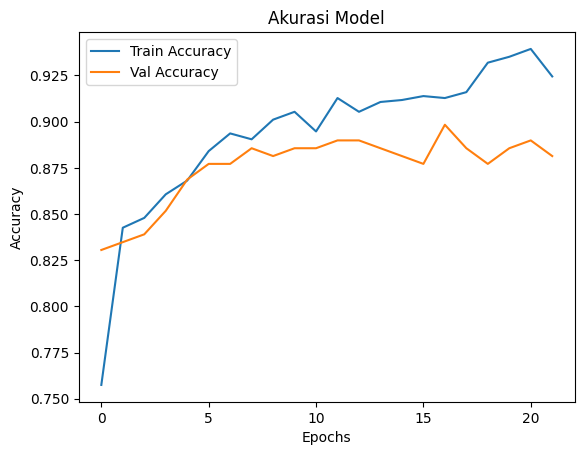

In [383]:
plt.plot(epochs_hist.history['accuracy'], label='Train Accuracy')
plt.plot(epochs_hist.history['val_accuracy'], label='Val Accuracy')
plt.title('Akurasi Model')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

Interpretasi Grafik Akurasi,
* Tran Accuracy (biru) terus naik sekitar 0.93-0.94
* Validation Accuracy (orange) juga tinggi dan stabil dikisaran 0.87-0.89, tanpa turun naik drastis diakhir (tdk overfit signifikan)
* Jarak antara train & val acuracy masih wajar (< 0.06) (0.94-0.88), yg artinya model masih bisa generalisasai dg baik pada data baru.
* Model tidak underfit maupun overfit

Accuracy Curve
**Tujuan**

Mengevaluasi perkembangan akurasi model selama proses pelatihan untuk melihat apakah model mampu mempelajari pola dari data training sekaligus mempertahankan performa yang baik pada data validasi.

**Insight**
Akurasi training terus meningkat secara bertahap hingga mencapai sekitar 93–94%, yang menunjukkan bahwa model semakin baik dalam mempelajari pola pada data training.
Akurasi validasi juga meningkat dan stabil di kisaran 87–89% tanpa mengalami penurunan yang signifikan pada akhir pelatihan.
Selisih antara akurasi training dan validasi relatif kecil (sekitar 5–6%), sehingga menunjukkan bahwa model masih mampu melakukan generalisasi dengan baik pada data yang belum pernah dilihat.

**Why It Matters**
Kurva akurasi menunjukkan bahwa model berhasil mempelajari pola dari data training dan tetap mempertahankan performa yang stabil pada data validasi. Hal ini mengindikasikan bahwa model memiliki kemampuan generalisasi yang baik tanpa menunjukkan indikasi overfitting yang signifikan

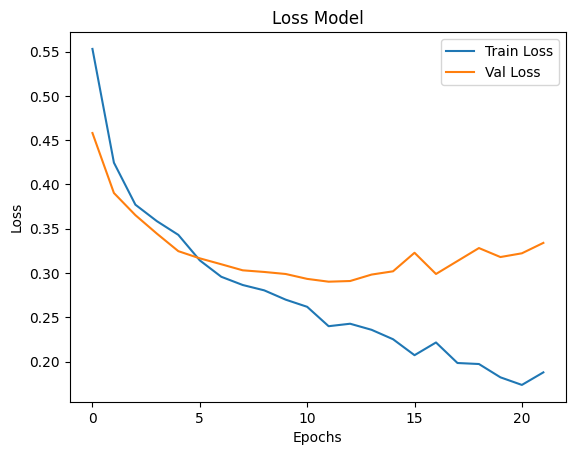

In [384]:
plt.plot(epochs_hist.history['loss'], label='Train Loss')
plt.plot(epochs_hist.history['val_loss'], label='Val Loss')
plt.title('Loss Model')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

Analisa Grafik Val loss,
* Garis biru (TrainLoss) turun menurun scara stabil - artinya model belajar dari data train.
* Garis orange (Validation loss) juga menurun diawal lalu cenderung tidak naik tajam. Jadi tidak ada tanda overfitting serius
* Artinya apa? model sudah jauh lebih sehat dibanding grafik sebelumnya.
* Sekarang model sdh bisa belajar dari data tanpa perlu menghafal.

**Tujuan**

Mengevaluasi perubahan nilai loss selama proses pelatihan untuk memastikan bahwa model mampu meminimalkan kesalahan prediksi pada data training maupun data validasi.

**Insight**
Nilai training loss terus menurun secara konsisten, menunjukkan bahwa model semakin baik dalam mempelajari data training.
Validation loss juga menurun pada beberapa epoch awal, kemudian cenderung stabil tanpa peningkatan yang tajam.
Pola tersebut menunjukkan bahwa proses pelatihan berjalan stabil dan model telah mencapai kondisi konvergen tanpa indikasi overfitting yang serius.

**Why It Matters**
Kurva loss menunjukkan bahwa model tidak hanya berhasil mengurangi kesalahan pada data training, tetapi juga mampu mempertahankan performa yang stabil pada data validasi. Hal ini menunjukkan bahwa model mempelajari pola yang relevan dan memiliki kemampuan generalisasi yang baik.